Nomes: Vitoria Ayres (2086138) e Leticia Ribeiro (2034293)

### Importação e configuração do ambiente

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score, RocCurveDisplay, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

dataset=pd.read_csv("glass.csv")
dataset.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### Exploração do Dataset

In [31]:
print("=== INFO DO DATASET ===")
dataset.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(dataset.describe())

print("\n=== DISTRIBUIÇÃO DE CLASSES ===")
print(dataset['Type'].value_counts())


=== INFO DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

=== ESTATÍSTICAS DESCRITIVAS ===
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150 

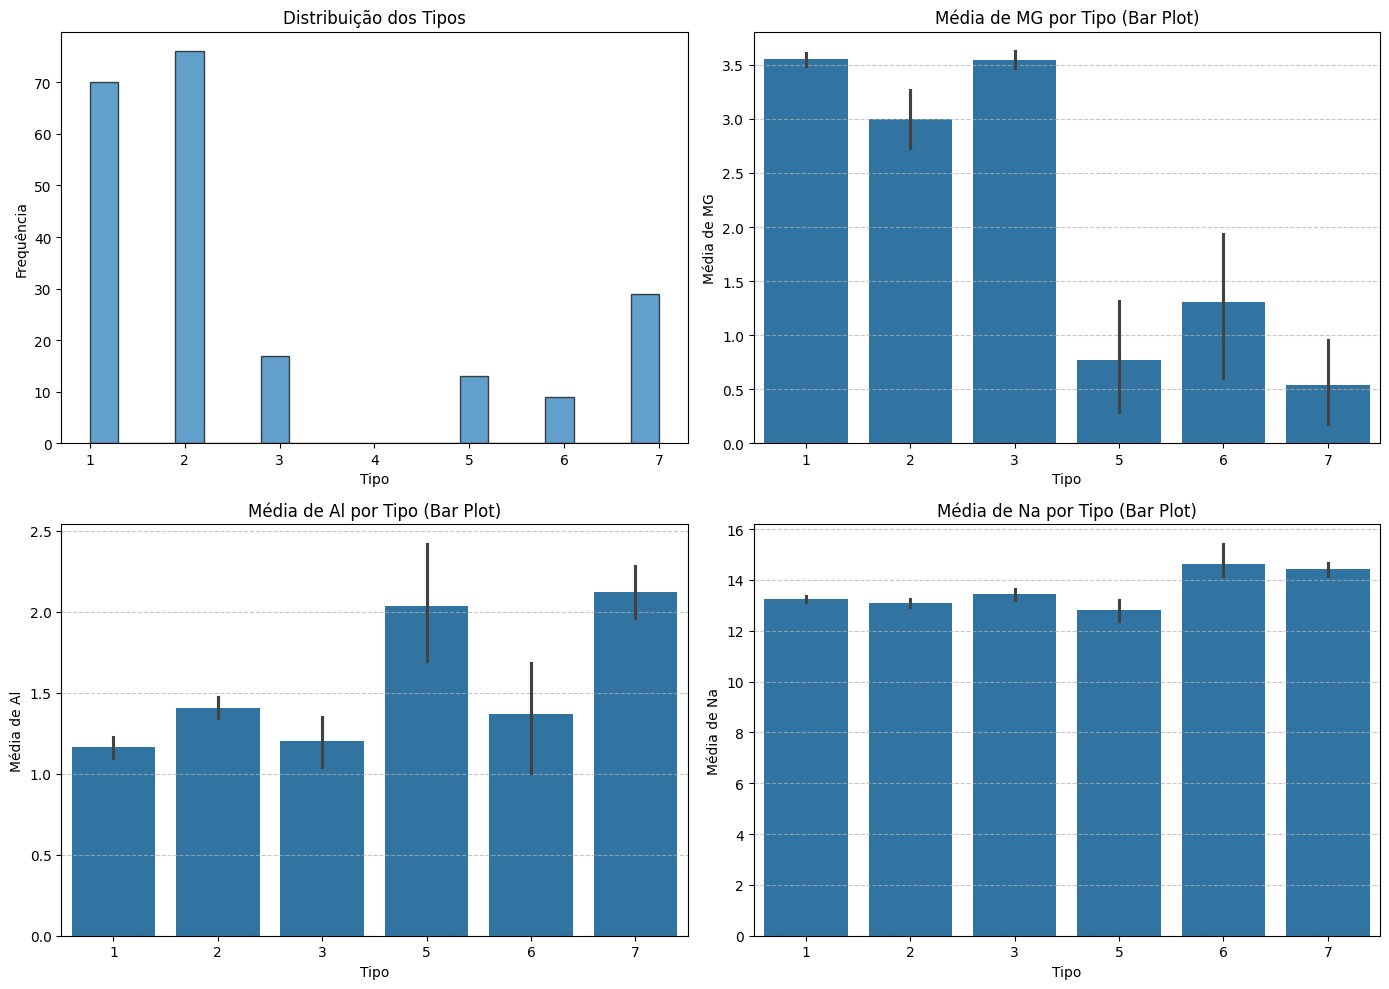

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(dataset['Type'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Tipo')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição dos Tipos')

sns.barplot(x='Type', y='Al', data=dataset, estimator=np.mean, errorbar=('ci', 95), ax=axes[1,0])
axes[1,0].set_title('Média de Al por Tipo (Bar Plot)')
axes[1,0].set_xlabel('Tipo')
axes[1,0].set_ylabel('Média de Al')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Type', y='Mg', data=dataset, estimator=np.mean, errorbar=('ci', 95), ax=axes[0,1])
axes[0,1].set_title('Média de MG por Tipo (Bar Plot)')
axes[0,1].set_xlabel('Tipo')
axes[0,1].set_ylabel('Média de MG')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Type', y='Na', data=dataset, estimator=np.mean, errorbar=('ci', 95), ax=axes[1,1])
axes[1,1].set_title('Média de Na por Tipo (Bar Plot)')
axes[1,1].set_xlabel('Tipo')
axes[1,1].set_ylabel('Média de Na')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

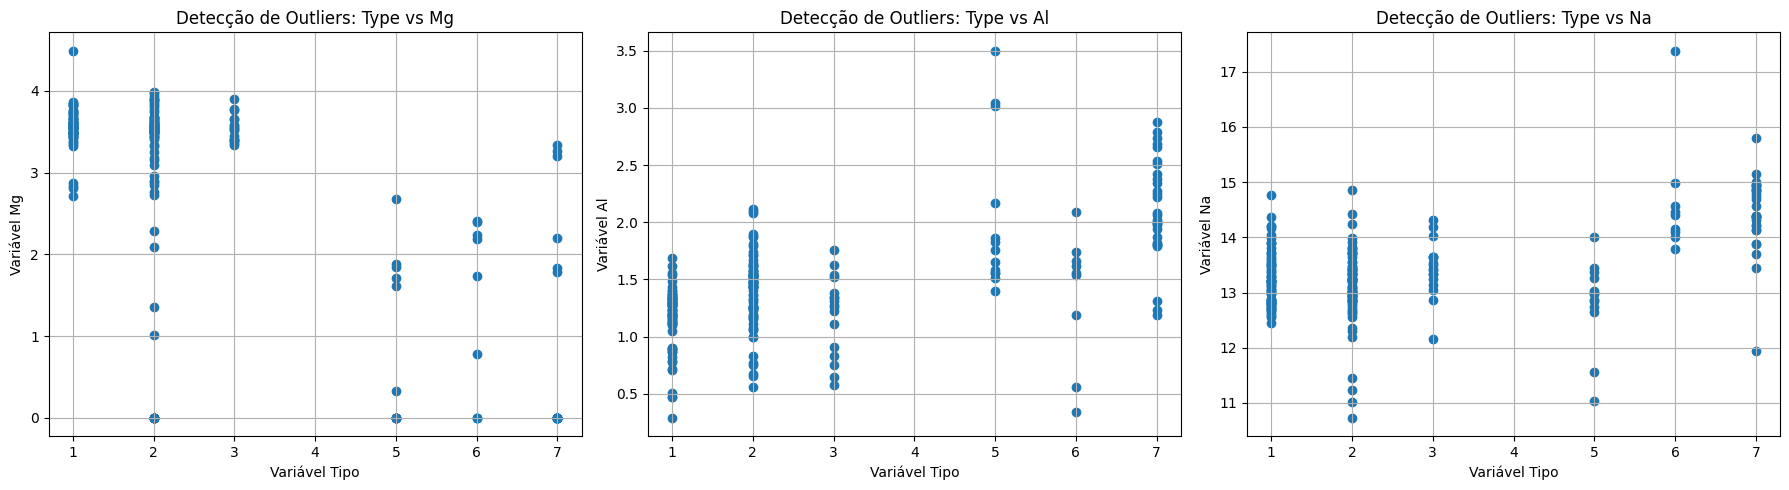

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(dataset["Type"], y=dataset["Mg"])
axes[0].set_title('Detecção de Outliers: Type vs Mg')
axes[0].set_xlabel('Variável Tipo')
axes[0].set_ylabel('Variável Mg')
axes[0].grid(True)

axes[1].scatter(dataset["Type"], y=dataset["Al"])
axes[1].set_title('Detecção de Outliers: Type vs Al')
axes[1].set_xlabel('Variável Tipo')
axes[1].set_ylabel('Variável Al')
axes[1].grid(True)

axes[2].scatter(dataset["Type"], y=dataset["Na"])
axes[2].set_title('Detecção de Outliers: Type vs Na')
axes[2].set_xlabel('Variável Tipo')
axes[2].set_ylabel('Variável Na')
axes[2].grid(True)

plt.tight_layout()
plt.show()

=== DETECÇÃO DE OUTLIERS (IQR) ===
\Mg - Estatísticas:
Q1: 2.11
Q3: 3.60
IQR: 1.49

Limites:
Lower bound: -0.11
Upper bound: 5.83

Outliers detectados: 0 (0.0%)


<>:16: SyntaxWarning: invalid escape sequence '\M'
<>:16: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_1791/3496913437.py:16: SyntaxWarning: invalid escape sequence '\M'
  print(f"\Mg - Estatísticas:")


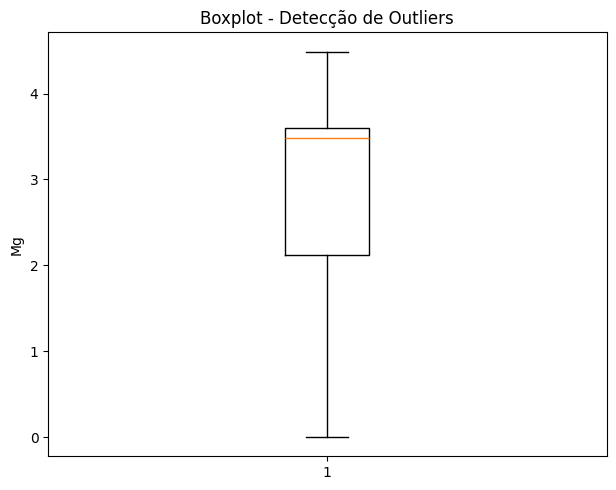

In [35]:
print("=== DETECÇÃO DE OUTLIERS (IQR) ===")

def detect_outliers_iqr(series):
    """Detecta outliers usando IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers, lower_bound, upper_bound

mg = dataset["Mg"]
outliers, lower, upper = detect_outliers_iqr(mg)

print(f"\Mg - Estatísticas:")
print(f"Q1: {mg.quantile(0.25):.2f}")
print(f"Q3: {mg.quantile(0.75):.2f}")
print(f"IQR: {(mg.quantile(0.75) - mg.quantile(0.25)):.2f}")
print(f"\nLimites:")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"\nOutliers detectados: {outliers.sum()} ({outliers.sum()/len(mg)*100:.1f}%)")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(mg, vert=True)
plt.ylabel('Mg')
plt.title('Boxplot - Detecção de Outliers')

plt.tight_layout()
plt.show()

=== DETECÇÃO DE OUTLIERS (IQR) ===

Al - Estatísticas:
Q1: 1.19
Q3: 1.63
IQR: 0.44

Limites:
Lower bound: 0.53
Upper bound: 2.29

Outliers detectados: 18 (8.4%)


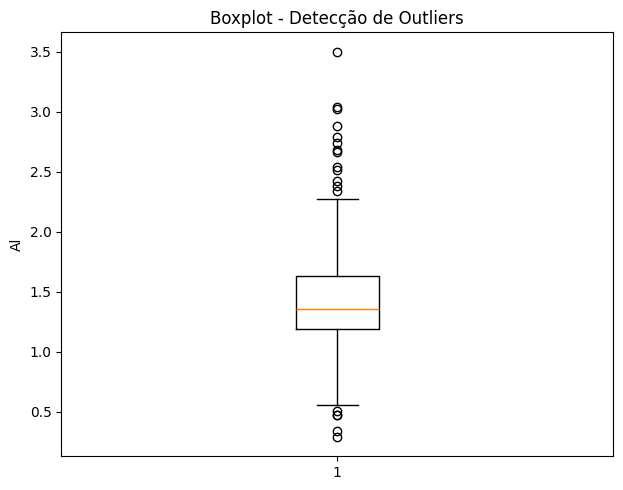

In [36]:
print("=== DETECÇÃO DE OUTLIERS (IQR) ===")

def detect_outliers_iqr(series):
    """Detecta outliers usando IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers, lower_bound, upper_bound

al = dataset["Al"]
outliers, lower, upper = detect_outliers_iqr(al)

print(f"\nAl - Estatísticas:")
print(f"Q1: {al.quantile(0.25):.2f}")
print(f"Q3: {al.quantile(0.75):.2f}")
print(f"IQR: {(al.quantile(0.75) - al.quantile(0.25)):.2f}")
print(f"\nLimites:")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"\nOutliers detectados: {outliers.sum()} ({outliers.sum()/len(al)*100:.1f}%)")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(al, vert=True)
plt.ylabel('Al')
plt.title('Boxplot - Detecção de Outliers')

plt.tight_layout()
plt.show()

=== DETECÇÃO DE OUTLIERS (IQR) ===

Na - Estatísticas:
Q1: 12.91
Q3: 13.82
IQR: 0.92

Limites:
Lower bound: 11.53
Upper bound: 15.20

Outliers detectados: 7 (3.3%)


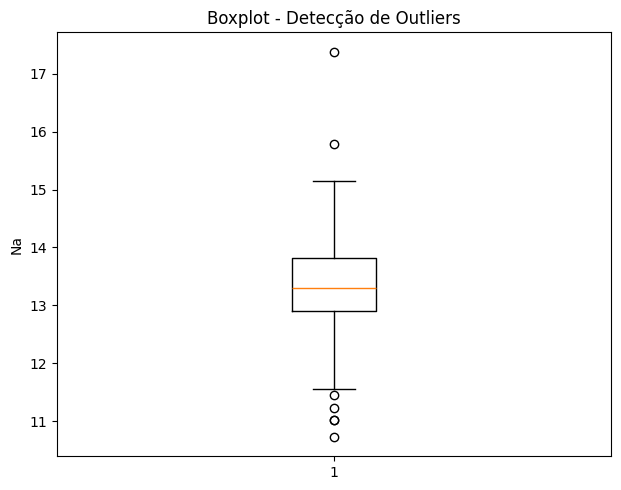

In [37]:
print("=== DETECÇÃO DE OUTLIERS (IQR) ===")

def detect_outliers_iqr(series):
    """Detecta outliers usando IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers, lower_bound, upper_bound

na = dataset["Na"]
outliers, lower, upper = detect_outliers_iqr(na)

print(f"\nNa - Estatísticas:")
print(f"Q1: {na.quantile(0.25):.2f}")
print(f"Q3: {na.quantile(0.75):.2f}")
print(f"IQR: {(na.quantile(0.75) - na.quantile(0.25)):.2f}")
print(f"\nLimites:")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"\nOutliers detectados: {outliers.sum()} ({outliers.sum()/len(na)*100:.1f}%)")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(na, vert=True)
plt.ylabel('Na')
plt.title('Boxplot - Detecção de Outliers')

plt.tight_layout()
plt.show()

### Divisão entre Treino, Teste, Validação e Escalonando os Dados

In [38]:
X=dataset.drop(columns="Type")
y=dataset["Type"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler= StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print("=== VIDRO DATASET ===")
print(f"Features: {X.columns}")
print(f"Classes: {dataset["Type"].unique()}")
print(f"Train: {X_train.shape[0]} amostras ({X_train.shape[0] / X.shape[0] * 100:.1f}%)")
print(f"Val:   {X_val.shape[0]} amostras ({X_val.shape[0] / X.shape[0] * 100:.1f}%)")
print(f"Test:  {X_test.shape[0]} amostras ({X_test.shape[0] / X.shape[0] * 100:.1f}%)")

=== VIDRO DATASET ===
Features: Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')
Classes: [1 2 3 5 6 7]
Train: 128 amostras (59.8%)
Val:   43 amostras (20.1%)
Test:  43 amostras (20.1%)


###PCA


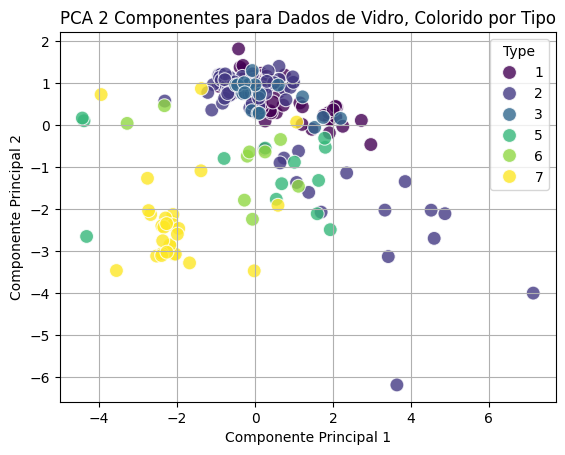

In [39]:
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
pca_df['Type'] = y

sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Type',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('PCA 2 Componentes para Dados de Vidro, Colorido por Tipo')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

### Procurando o Melhor K para o KNClassifier

In [40]:
k_valores = [1, 3, 5, 7, 15]
print(f"{'K':>4}  {'Train':>8}  {'Val':>8}")
print("-" * 24)

for k in  k_valores:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_sc, y_train)

    acc_tr = modelo_k.score(X_train_sc, y_train)
    acc_va = modelo_k.score(X_val_sc, y_val)

    print(f"{k:>4}  {acc_tr:>8.4f}  {acc_va:>8.4f}")

   K     Train       Val
------------------------
   1    1.0000    0.8372
   3    0.7969    0.6512
   5    0.7109    0.6279
   7    0.6719    0.6279
  15    0.6406    0.6047


### Treinando Modelo KNClassifier

In [41]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_sc, y_train)

acc_train = knn.score(X_train_sc, y_train)
acc_val = knn.score(X_val_sc, y_val)
acc_test = knn.score(X_test_sc, y_test)

model_test_knn = knn.predict(X_test_sc)

print("=== KNN (K = 3) | VIDRO  ===")
print(f"Acurácia Train: {acc_train:.4f}")
print(f"Acurácia Val:   {acc_val:.4f}")
print(f"Acurácia Test:  {acc_test:.4f}")
print()

class_labels_str = []
for label in sorted(dataset["Type"].unique()):
    class_labels_str.append(str(label))

print(classification_report(y_test, model_test_knn, target_names=class_labels_str))

=== KNN (K = 3) | VIDRO  ===
Acurácia Train: 0.7969
Acurácia Val:   0.6512
Acurácia Test:  0.7209

              precision    recall  f1-score   support

           1       0.65      0.93      0.76        14
           2       0.83      0.67      0.74        15
           3       0.00      0.00      0.00         3
           5       1.00      0.33      0.50         3
           6       1.00      0.50      0.67         2
           7       0.75      1.00      0.86         6

    accuracy                           0.72        43
   macro avg       0.71      0.57      0.59        43
weighted avg       0.72      0.72      0.69        43



###Matriz de Confusão - KNClassifier

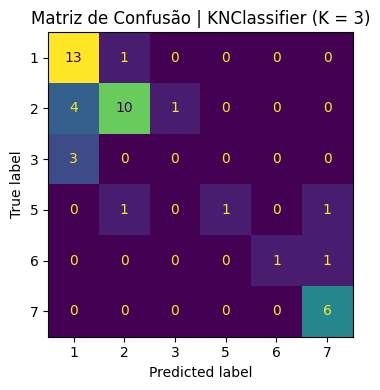

In [43]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_test_knn,
    ax=ax,
    display_labels=class_labels_str,
    colorbar=False
)
ax.set_title("Matriz de Confusão | KNClassifier (K = 3)")
plt.tight_layout()
plt.show()

### K-FOLD do KNClassifier

In [42]:
print("=== CROSS-VALIDATION ===")


kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- K-FOLD CROSS-VALIDATION ---")

scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')
print(f"\nKNClassifier:")
print(f"  Scores por fold: {scores}")
print(f"  Média: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")


=== CROSS-VALIDATION ===

--- K-FOLD CROSS-VALIDATION ---

KNClassifier:
  Scores por fold: [0.65384615 0.61538462 0.61538462 0.56       0.56      ]
  Média: 0.6009 (+/- 0.0725)


### ROC/AUC via One-vs-Rest - KNClassifier

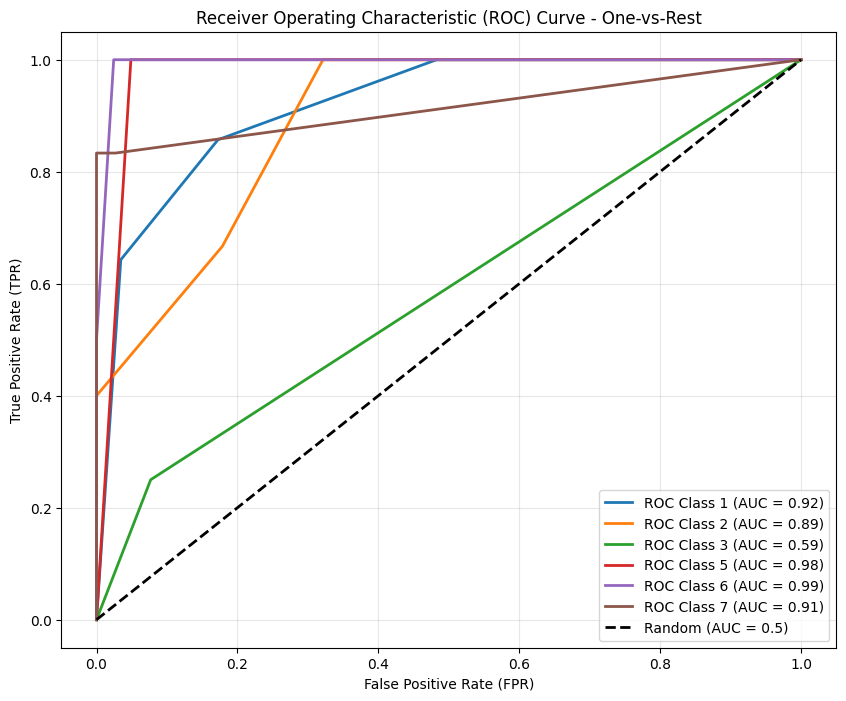

=== AUC Scores (One-vs-Rest) ===
Class 1: AUC = 0.9200
Class 2: AUC = 0.8929
Class 3: AUC = 0.5865
Class 5: AUC = 0.9756
Class 6: AUC = 0.9939
Class 7: AUC = 0.9144


In [44]:
y_pred = knn.predict(X_val_sc)
y_proba = knn.predict_proba(X_val_sc)

plt.figure(figsize=(10, 8))

classes = sorted(dataset["Type"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

auc_scores = {}

for i, class_label in enumerate(classes):

    y_true_binary = (y_val == class_label).astype(int)



    if class_label in knn.classes_:
        class_idx_in_model = list(knn.classes_).index(class_label)
        y_score_class = y_proba[:, class_idx_in_model]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score_class)
        roc_auc = auc(fpr, tpr)
        auc_scores[str(class_label)] = roc_auc

        plt.plot(fpr, tpr, linewidth=2, label=f'ROC Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print("=== AUC Scores (One-vs-Rest) ===")
for cls, score in auc_scores.items():
    print(f"Class {cls}: AUC = {score:.4f}")


### SVM - Melhor Parametros

In [45]:
print("TESTANDO HIPERPARÂMETROS DO SVM")
print(f"{'Kernel':<10}  {'C':<8}  {'Train':>8}  {'Val':>8}")
print("-" * 40)

c_valores = [0.1, 1, 10]
kernels = ['linear', 'rbf']

melhor_val = 0
melhor_params = {}

for kernel in kernels:
    for c in c_valores:
        modelo_svm = SVC(kernel=kernel, C=c, random_state=42)
        modelo_svm.fit(X_train_sc, y_train)

        acc_tr = modelo_svm.score(X_train_sc, y_train)
        acc_va = modelo_svm.score(X_val_sc, y_val)

        print(f"{kernel:<10}  {c:<8}  {acc_tr:>8.4f}  {acc_va:>8.4f}")

        if acc_va > melhor_val:
            melhor_val = acc_va
            melhor_params = {'kernel': kernel, 'C': c}

print(f"Melhores parâmetros: {melhor_params}")


TESTANDO HIPERPARÂMETROS DO SVM
Kernel      C            Train       Val
----------------------------------------
linear      0.1         0.6406    0.6279
linear      1           0.6875    0.6977
linear      10          0.7344    0.6512
rbf         0.1         0.4375    0.4651
rbf         1           0.7969    0.7209
rbf         10          0.8672    0.7674
Melhores parâmetros: {'kernel': 'rbf', 'C': 10}


###SVM - Treino

In [46]:
svm = SVC(kernel=melhor_params['kernel'], C=melhor_params['C'], probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

acc_train_svm = svm.score(X_train_sc, y_train)
acc_val_svm = svm.score(X_val_sc, y_val)
acc_test_svm = svm.score(X_test_sc, y_test)

model_test_svm = svm.predict(X_test_sc)

print(f"SVM ({melhor_params['kernel'].upper()}, C={melhor_params['C']}) | VIDRO")
print(f"Acurácia Train: {acc_train_svm:.4f}")
print(f"Acurácia Val:   {acc_val_svm:.4f}")
print(f"Acurácia Test:  {acc_test_svm:.4f}")
print()

print(classification_report(y_test, model_test_svm, target_names=class_labels_str))

SVM (RBF, C=10) | VIDRO
Acurácia Train: 0.8672
Acurácia Val:   0.7674
Acurácia Test:  0.7209

              precision    recall  f1-score   support

           1       0.67      0.86      0.75        14
           2       0.71      0.67      0.69        15
           3       0.00      0.00      0.00         3
           5       1.00      0.67      0.80         3
           6       0.50      0.50      0.50         2
           7       0.86      1.00      0.92         6

    accuracy                           0.72        43
   macro avg       0.62      0.62      0.61        43
weighted avg       0.68      0.72      0.69        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### SVM - Matriz de Confusão

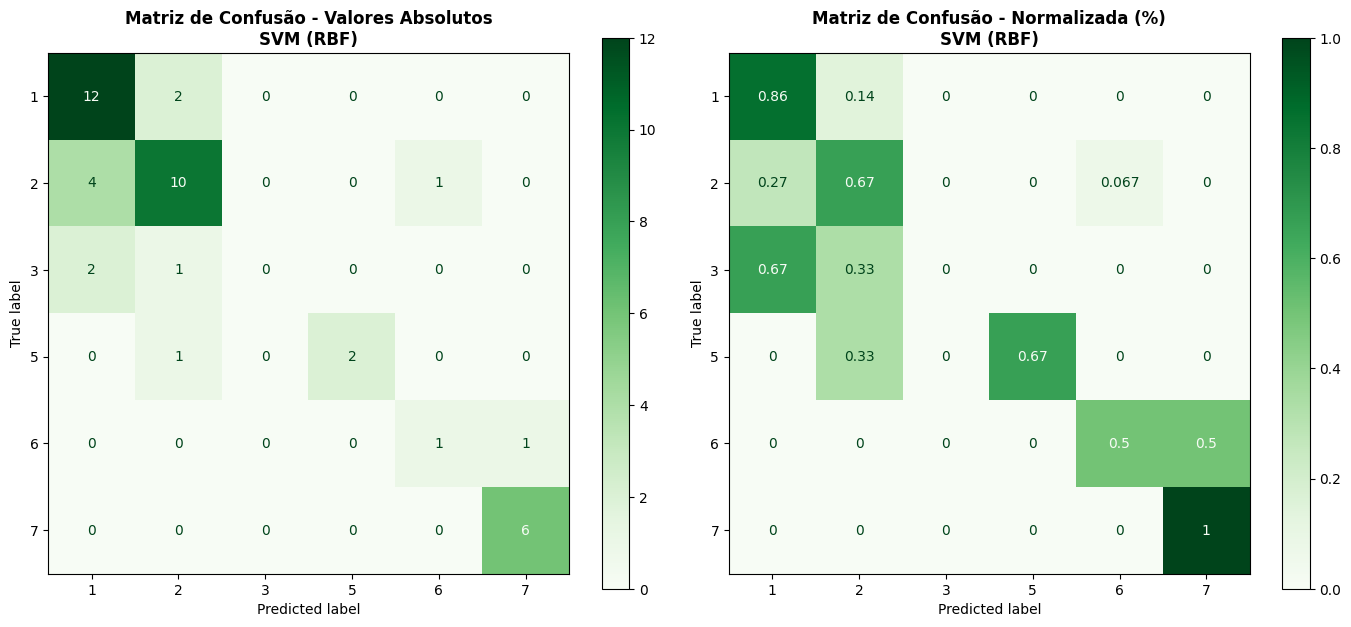

 ANÁLISE DA MATRIZ DE CONFUSÃO (SVM)
Classes com maior taxa de erro:
Classe 1: 12/14 corretos (85.7%)
  Principais confusões: Classe 2 (2x) 
Classe 2: 10/15 corretos (66.7%)
  Principais confusões: Classe 1 (4x) Classe 6 (1x) 
Classe 3: 0/3 corretos (0.0%)
  Principais confusões: Classe 1 (2x) Classe 2 (1x) 
Classe 5: 2/3 corretos (66.7%)
  Principais confusões: Classe 2 (1x) 
Classe 6: 1/2 corretos (50.0%)
  Principais confusões: Classe 7 (1x) 
Classe 7: 6/6 corretos (100.0%)


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_test_svm,
    ax=axes[0],
    display_labels=class_labels_str,
    cmap='Greens',
    colorbar=True
)
axes[0].set_title(f"Matriz de Confusão - Valores Absolutos\nSVM ({melhor_params['kernel'].upper()})", fontsize=12, fontweight='bold')
axes[0].grid(False)

# Matriz de Confusão - Normalizada (%)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_test_svm,
    ax=axes[1],
    display_labels=class_labels_str,
    cmap='Greens',
    colorbar=True,
    normalize='true'
)
axes[1].set_title(f"Matriz de Confusão - Normalizada (%)\nSVM ({melhor_params['kernel'].upper()})", fontsize=12, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()


cm_svm = confusion_matrix(y_test, model_test_svm)
print(" ANÁLISE DA MATRIZ DE CONFUSÃO (SVM)")
print("Classes com maior taxa de erro:")
for i, class_label in enumerate(sorted(dataset["Type"].unique())):
    total = cm_svm[i].sum()
    correct = cm_svm[i, i]
    accuracy = correct / total if total > 0 else 0
    print(f"Classe {class_label}: {correct}/{total} corretos ({accuracy*100:.1f}%)")

    # Mostrar principais confusões
    if total > 0:
        errors = [(j, cm_svm[i, j]) for j in range(len(cm_svm[i])) if i != j and cm_svm[i, j] > 0]
        if errors:
            errors.sort(key=lambda x: x[1], reverse=True)
            print(f"  Principais confusões: ", end="")
            for j, count in errors[:2]:
                print(f"Classe {sorted(dataset['Type'].unique())[j]} ({count}x) ", end="")
            print()

###SVM - K-Fold

In [48]:
print("CROSS-VALIDATION (SVM)")

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("STRATIFIED K-FOLD CROSS-VALIDATION")

scores_svm = cross_val_score(svm, X_train_sc, y_train, cv=skfold, scoring='accuracy')
print(f"\nSVM ({melhor_params['kernel'].upper()}):")
print(f"  Scores por fold: {scores_svm}")
print(f"  Média: {scores_svm.mean():.4f} (+/- {scores_svm.std()*2:.4f})")

CROSS-VALIDATION (SVM)
STRATIFIED K-FOLD CROSS-VALIDATION

SVM (RBF):
  Scores por fold: [0.65384615 0.65384615 0.61538462 0.56       0.76      ]
  Média: 0.6486 (+/- 0.1309)


###SVM - ROC/AUC via One-vs-Rest

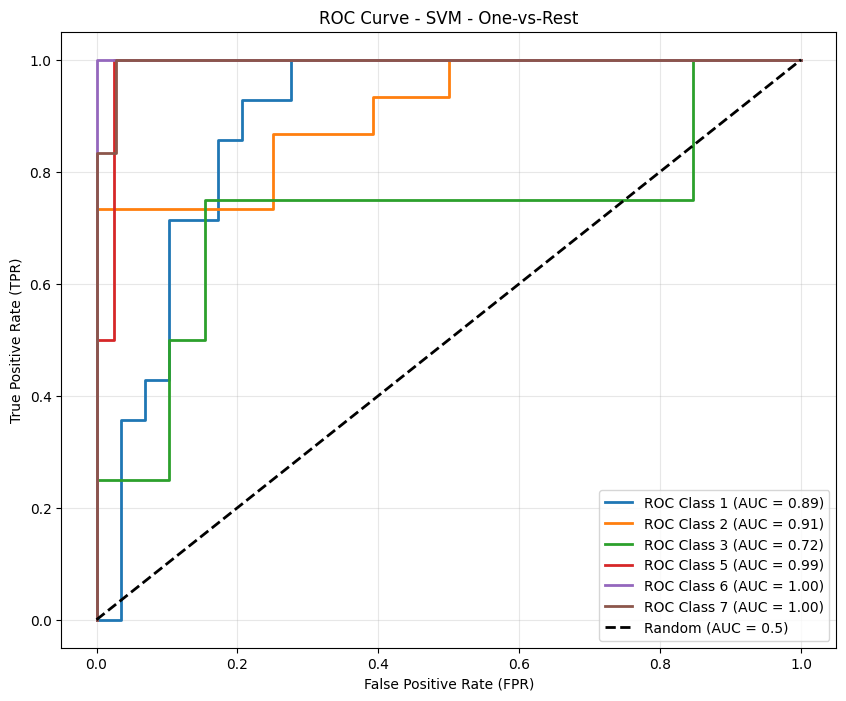

 AUC Scores (One-vs-Rest) - SVM
Class 1: AUC = 0.8941
Class 2: AUC = 0.9071
Class 3: AUC = 0.7244
Class 5: AUC = 0.9878
Class 6: AUC = 1.0000
Class 7: AUC = 0.9955


In [49]:
y_pred_svm = svm.predict(X_val_sc)
y_proba_svm = svm.predict_proba(X_val_sc)

plt.figure(figsize=(10, 8))

auc_scores_svm = {}

for i, class_label in enumerate(classes):
    y_true_binary = (y_val == class_label).astype(int)

    if class_label in svm.classes_:
        class_idx_in_model = list(svm.classes_).index(class_label)
        y_score_class = y_proba_svm[:, class_idx_in_model]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score_class)
        roc_auc = auc(fpr, tpr)
        auc_scores_svm[str(class_label)] = roc_auc

        plt.plot(fpr, tpr, linewidth=2, label=f'ROC Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - SVM - One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(" AUC Scores (One-vs-Rest) - SVM")
for cls, score in auc_scores_svm.items():
    print(f"Class {cls}: AUC = {score:.4f}")

###Naive Bayes - Treino

In [50]:
nb = GaussianNB()
nb.fit(X_train_sc, y_train)

acc_train_nb = nb.score(X_train_sc, y_train)
acc_val_nb = nb.score(X_val_sc, y_val)
acc_test_nb = nb.score(X_test_sc, y_test)

model_test_nb = nb.predict(X_test_sc)

print("NAIVE BAYES (GaussianNB) | VIDRO ")
print(f"Acurácia Train: {acc_train_nb:.4f}")
print(f"Acurácia Val:   {acc_val_nb:.4f}")
print(f"Acurácia Test:  {acc_test_nb:.4f}")
print()

print(classification_report(y_test, model_test_nb, target_names=class_labels_str))

NAIVE BAYES (GaussianNB) | VIDRO 
Acurácia Train: 0.5938
Acurácia Val:   0.4651
Acurácia Test:  0.5581

              precision    recall  f1-score   support

           1       0.54      1.00      0.70        14
           2       0.50      0.13      0.21        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.50      1.00      0.67         2
           7       0.75      1.00      0.86         6

    accuracy                           0.56        43
   macro avg       0.38      0.52      0.41        43
weighted avg       0.48      0.56      0.45        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Naive Bayes - Matriz de Confusão

<>:30: SyntaxWarning: invalid escape sequence '\A'
<>:30: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1791/2960055910.py:30: SyntaxWarning: invalid escape sequence '\A'
  print("\ANÁLISE DA MATRIZ DE CONFUSÃO (NAIVE BAYES)")


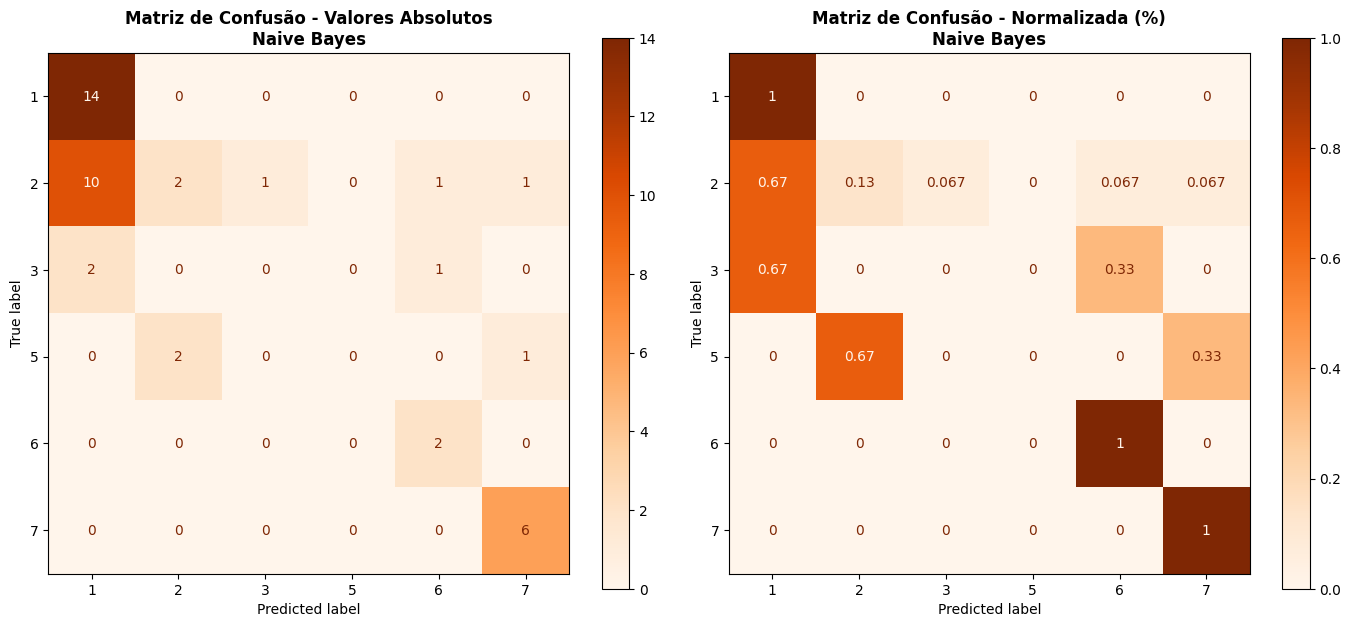

\ANÁLISE DA MATRIZ DE CONFUSÃO (NAIVE BAYES)

Classes com maior taxa de erro:
Classe 1: 14/14 corretos (100.0%)
Classe 2: 2/15 corretos (13.3%)
  Principais confusões: Classe 1 (10x) Classe 3 (1x) 
Classe 3: 0/3 corretos (0.0%)
  Principais confusões: Classe 1 (2x) Classe 6 (1x) 
Classe 5: 0/3 corretos (0.0%)
  Principais confusões: Classe 2 (2x) Classe 7 (1x) 
Classe 6: 2/2 corretos (100.0%)
Classe 7: 6/6 corretos (100.0%)


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_test_nb,
    ax=axes[0],
    display_labels=class_labels_str,
    cmap='Oranges',
    colorbar=True
)
axes[0].set_title("Matriz de Confusão - Valores Absolutos\nNaive Bayes", fontsize=12, fontweight='bold')
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_test_nb,
    ax=axes[1],
    display_labels=class_labels_str,
    cmap='Oranges',
    colorbar=True,
    normalize='true'
)
axes[1].set_title("Matriz de Confusão - Normalizada (%)\nNaive Bayes", fontsize=12, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

cm_nb = confusion_matrix(y_test, model_test_nb)
print("\ANÁLISE DA MATRIZ DE CONFUSÃO (NAIVE BAYES)")
print("\nClasses com maior taxa de erro:")
for i, class_label in enumerate(sorted(dataset["Type"].unique())):
    total = cm_nb[i].sum()
    correct = cm_nb[i, i]
    accuracy = correct / total if total > 0 else 0
    print(f"Classe {class_label}: {correct}/{total} corretos ({accuracy*100:.1f}%)")

    if total > 0:
        errors = [(j, cm_nb[i, j]) for j in range(len(cm_nb[i])) if i != j and cm_nb[i, j] > 0]
        if errors:
            errors.sort(key=lambda x: x[1], reverse=True)
            print(f"  Principais confusões: ", end="")
            for j, count in errors[:2]:
                print(f"Classe {sorted(dataset['Type'].unique())[j]} ({count}x) ", end="")
            print()

###Naive Bayes - K-Fold

In [52]:
print("\CROSS-VALIDATION (NAIVE BAYES)")

print("\n--- STRATIFIED K-FOLD CROSS-VALIDATION ---")

scores_nb = cross_val_score(nb, X_train_sc, y_train, cv=skfold, scoring='accuracy')
print(f"\nNaive Bayes (GaussianNB):")
print(f"  Scores por fold: {scores_nb}")
print(f"  Média: {scores_nb.mean():.4f} (+/- {scores_nb.std()*2:.4f})")

\CROSS-VALIDATION (NAIVE BAYES)

--- STRATIFIED K-FOLD CROSS-VALIDATION ---

Naive Bayes (GaussianNB):
  Scores por fold: [0.57692308 0.53846154 0.46153846 0.4        0.24      ]
  Média: 0.4434 (+/- 0.2374)


<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_1791/1497962937.py:1: SyntaxWarning: invalid escape sequence '\C'
  print("\CROSS-VALIDATION (NAIVE BAYES)")


### Naive Bayes - ROC/AUC via One-vs-Rest

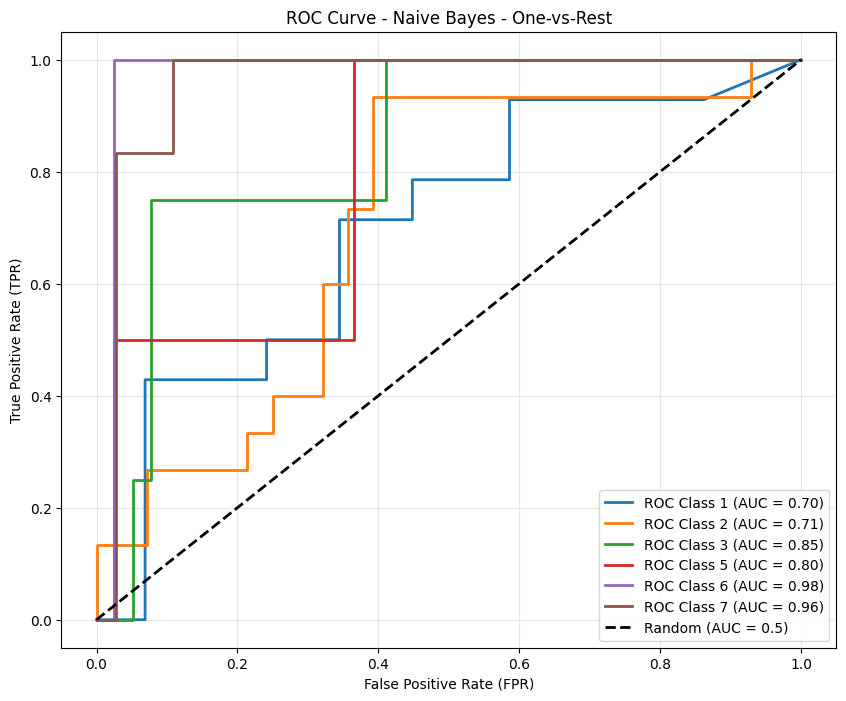


=== AUC Scores (One-vs-Rest) - NAIVE BAYES ===
Class 1: AUC = 0.6970
Class 2: AUC = 0.7071
Class 3: AUC = 0.8462
Class 5: AUC = 0.8049
Class 6: AUC = 0.9756
Class 7: AUC = 0.9595


In [53]:
y_pred_nb = nb.predict(X_val_sc)
y_proba_nb = nb.predict_proba(X_val_sc)

plt.figure(figsize=(10, 8))

auc_scores_nb = {}

for i, class_label in enumerate(classes):
    y_true_binary = (y_val == class_label).astype(int)

    if class_label in nb.classes_:
        class_idx_in_model = list(nb.classes_).index(class_label)
        y_score_class = y_proba_nb[:, class_idx_in_model]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score_class)
        roc_auc = auc(fpr, tpr)
        auc_scores_nb[str(class_label)] = roc_auc

        plt.plot(fpr, tpr, linewidth=2, label=f'ROC Class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Naive Bayes - One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== AUC Scores (One-vs-Rest) - NAIVE BAYES ===")
for cls, score in auc_scores_nb.items():
    print(f"Class {cls}: AUC = {score:.4f}")

###Comparação dos 3 Modelos

     Modelo  Acurácia
  KNN (K=3)   0.72093
        SVM   0.72093
Naive Bayes   0.55814


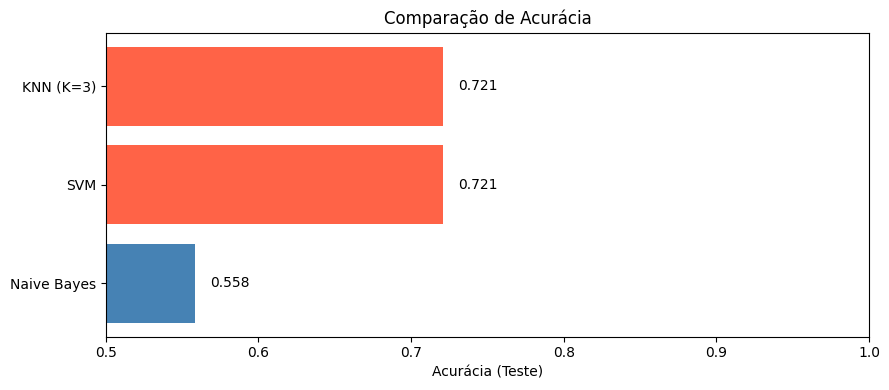

In [54]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_sc, y_train)

svm = SVC(kernel="rbf", C=10, probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

nb = GaussianNB()
nb.fit(X_train_sc, y_train)

modelos_todos = {
    "KNN (K=3)":             (knn, X_test_sc),
    "Naive Bayes":           (nb, X_test_sc),
    "SVM":                   (svm, X_test_sc)
}

resultados = []
for nome, (modelo, X_ev) in modelos_todos.items():
    acc = accuracy_score(y_test, modelo.predict(X_ev))
    resultados.append({"Modelo": nome, "Acurácia": acc})

df_res = pd.DataFrame(resultados).sort_values("Acurácia", ascending=False)

print(df_res.to_string(index=False))

plt.figure(figsize=(9, 4))
colors = ["tomato" if acc == df_res["Acurácia"].max() else "steelblue"
          for acc in df_res["Acurácia"]]

plt.barh(df_res["Modelo"], df_res["Acurácia"], color=colors)
plt.xlabel("Acurácia (Teste)")
plt.title("Comparação de Acurácia")
plt.xlim(0.5, 1.0)
plt.gca().invert_yaxis()

for i, v in enumerate(df_res["Acurácia"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

### Salvando os Modelos em Arquivos `.pkl`

In [55]:
import pickle

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_sc, y_train)

svm = SVC(kernel="rbf", C=10, probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

nb = GaussianNB()
nb.fit(X_train_sc, y_train)


with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn, f)
print("Modelo KNN salvo como 'knn_model.pkl'")


with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
print("Modelo SVM salvo como 'svm_model.pkl'")


with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb, f)
print("Modelo Naive Bayes salvo como 'nb_model.pkl'")

Modelo KNN salvo como 'knn_model.pkl'
Modelo SVM salvo como 'svm_model.pkl'
Modelo Naive Bayes salvo como 'nb_model.pkl'


In [56]:
import pickle

# Salvar o scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler salvo como 'scaler.pkl'")

Scaler salvo como 'scaler.pkl'
